In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Definir las funciones de activación y entrenamiento
def step_function(x):
  return np.where(x>= 0,1,0)

#Función para hacer predicciones
def perceptron_predict(x, weights1, weights2):
  y1 = step_function(np.dot(x, weights1[1:]) + weights1[0])
  y2 = step_function(np.dot(x, weights2[1:]) + weights2[0])

  return np.array([y1, y2])

In [ ]:
#Algoritmo de entrenamiento

def train(X, y1, y2,learning_rate = 0.1, epochs=10):
  weights1 = np.random.rand(X.shape[1] + 1)
  weights2 = np.random.rand(X.shape[1] + 1)
  error1 = []
  error2 = []
  for _ in range(epochs):
    total_error1 = 0
    total_error2 = 0
    for xi, target1, target2 in zip(X, y1, y2):
        output = perceptron_predict(xi, weights1, weights2)
        err1 = target1 - output[0]
        err2 = target2 - output[1]
        
        total_error1 += abs(err1)
        total_error2 += abs(err2)

        update1 = learning_rate * err1
        weights1[1:] += update1 * xi
        weights1[0] += update1

        update2 = learning_rate * err2
        weights2[1:] += update2 * xi
        weights2[0] += update2
    error1.append(total_error1)
    error2.append(total_error2)
  return weights1, weights2, error1, error2

Pesos entrenados para la neurona 1: [-0.37784639  0.12662396  0.30628565]
Pesos entrenados para la neurona 2: [-0.08739843  0.16213048  0.69620023]


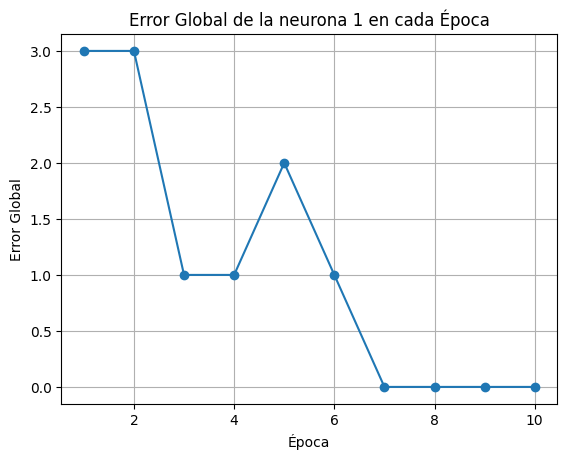

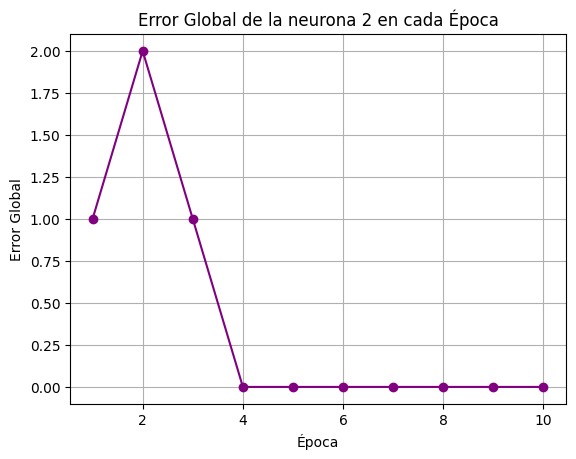

In [ ]:
# Preparar los datos de entrada y salida
# Datos de entrada para la compuerta AND
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Salidas esperadas para la compuerta AND
y = np.array([0, 0, 0, 1])
# Salidas esperadas para la compuerta OR
y1 = np.array([0, 1, 1, 1])

# Entrenar el perceptrón
weights1, weights2, errors, errors2 = train(X, y, y1, learning_rate=0.1, epochs=10)
print("Pesos entrenados para la neurona 1:", weights1)
print("Pesos entrenados para la neurona 2:", weights2)

# Graficar el error global en cada época para la neurona1
plt.figure(1)
plt.plot(range(1, len(errors) + 1), errors, marker='o')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global de la neurona 1 en cada Época')
plt.grid(True)
plt.show()

# Graficar el error global en cada época para la neurona2
plt.figure(2)
plt.plot(range(1, len(errors2) + 1), errors2, marker='o', color = 'purple')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global de la neurona 2 en cada Época')
plt.grid(True)
plt.show()




In [9]:
print('COMPUERTA AND')
for xi in X:
    prediction = perceptron_predict(xi, weights1, weights2)
    print(f"Entrada: {xi}, Salida predicha: {prediction[0]}")

print('\nCOMPUERTA OR')
for xi in X:
  prediction = perceptron_predict(xi, weights1, weights2)
  print(f"Entrada: {xi}, Salida predicha: {prediction[1]}")


COMPUERTA AND
Entrada: [0 0], Salida predicha: 0
Entrada: [0 1], Salida predicha: 0
Entrada: [1 0], Salida predicha: 0
Entrada: [1 1], Salida predicha: 1

COMPUERTA OR
Entrada: [0 0], Salida predicha: 0
Entrada: [0 1], Salida predicha: 1
Entrada: [1 0], Salida predicha: 1
Entrada: [1 1], Salida predicha: 1


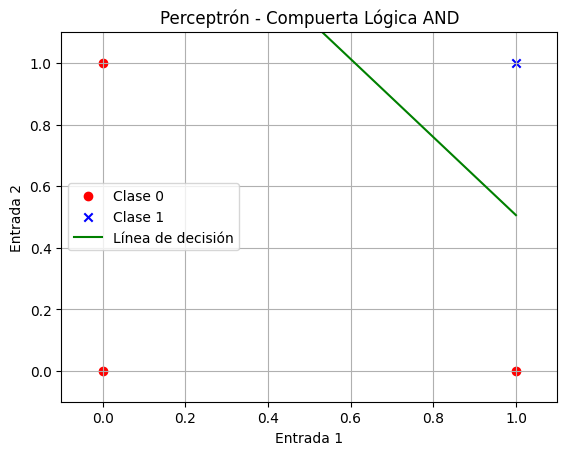

In [12]:
plt.figure(3)
# Graficar los puntos de datos para neurona 1
for i, xi in enumerate(X):
    if y[i] == 0:
        plt.scatter(xi[0], xi[1], color='red', marker='o', label='Clase 0' if i == 0 else "")
    else:
        plt.scatter(xi[0], xi[1], color='blue', marker='x', label='Clase 1' if i == 3 else "")

# Definir la línea de decisión
x_values = np.array([0, 1])
y_values = -(weights1[1] * x_values + weights1[0]) / weights1[2]

# Graficar la línea de decisión

plt.plot(x_values, y_values, label='Línea de decisión', color='green')

# Configuraciones de la gráfica
plt.xlabel('Entrada 1')
plt.ylabel('Entrada 2')
plt.legend()
plt.title('Perceptrón - Compuerta Lógica AND')
plt.grid(True)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# Mostrar la gráfica
plt.show()

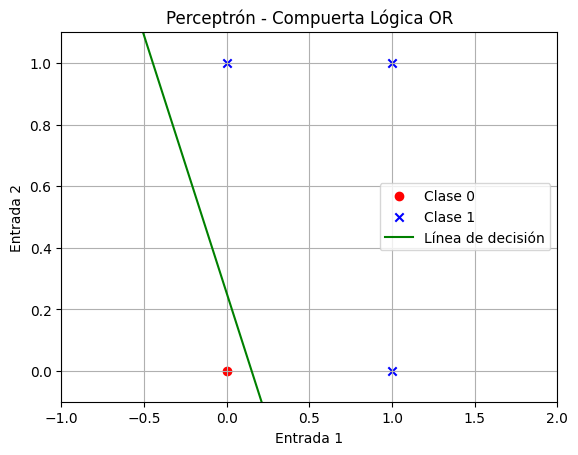

In [11]:
plt.figure(4)
# Graficar los puntos de datos para neurona 2
for i, xi in enumerate(X):
    if y1[i] == 0:
        plt.scatter(xi[0], xi[1], color='red', marker='o', label='Clase 0' if i == 0 else "")
    else:
        plt.scatter(xi[0], xi[1], color='blue', marker='x', label='Clase 1' if i == 3 else "")

x_values = np.array([-1,2])
y_values2 = -(weights2[1] * x_values + weights2[0]) / weights2[2]
#COMPUERTA OR

# Graficar la línea de decisión

plt.plot(x_values, y_values2, label='Línea de decisión', color='green')

# Configuraciones de la gráfica
plt.xlabel('Entrada 1')
plt.ylabel('Entrada 2')
plt.legend()
plt.title('Perceptrón - Compuerta Lógica OR')
plt.grid(True)
plt.xlim(-1, 2)
plt.ylim(-0.1, 1.1)

# Mostrar la gráfica
plt.show()
